<a href="https://colab.research.google.com/github/Pranitha3197/PROJECTS/blob/main/customer-segmentation-ml-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
d=pd.read_csv('/content/Mall_Customers.csv')
print(d)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


In [ ]:
d.shape

(200, 5)

In [ ]:
d['Genre'] = d['Genre'].map({'Male': 1, 'Female': 0})
print(d)

     CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1      1   19                  15                      39
1             2      1   21                  15                      81
2             3      0   20                  16                       6
3             4      0   23                  16                      77
4             5      0   31                  17                      40
..          ...    ...  ...                 ...                     ...
195         196      0   35                 120                      79
196         197      0   45                 126                      28
197         198      1   32                 126                      74
198         199      1   32                 137                      18
199         200      1   30                 137                      83

[200 rows x 5 columns]


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [ ]:
d.describe()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,0.440000,38.850000,60.560000,50.200000
std,57.879185,0.497633,13.969007,26.264721,25.823522
min,1.000000,0.000000,18.000000,15.000000,1.000000
25%,50.750000,0.000000,28.750000,41.500000,34.750000
50%,100.500000,0.000000,36.000000,61.500000,50.000000
75%,150.250000,1.000000,49.000000,78.000000,73.000000
max,200.000000,1.000000,70.000000,137.000000,99.000000


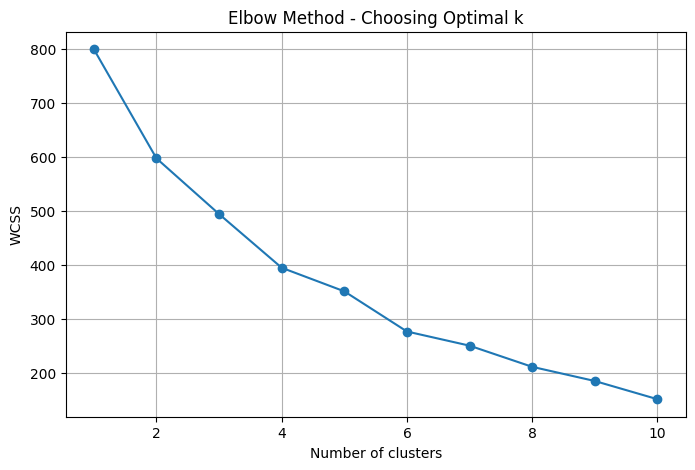

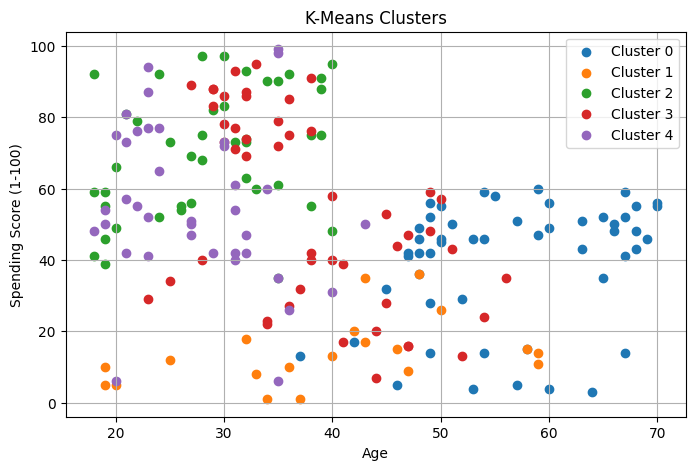

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      1   19                  15                      39        2
1           2      1   21                  15                      81        2
2           3      0   20                  16                       6        4
3           4      0   23                  16                      77        4
4           5      0   31                  17                      40        4


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/content/Mall_Customers.csv")
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - Choosing Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8,5))
for cluster in range(k):
    plt.scatter(df[df['Cluster'] == cluster]['Age'],
                df[df['Cluster'] == cluster]['Spending Score (1-100)'],
                label=f'Cluster {cluster}')
plt.title('K-Means Clusters')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()
print(df.head())

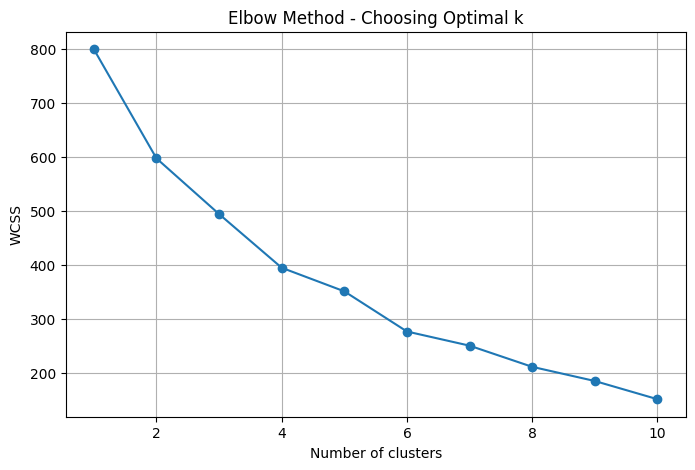

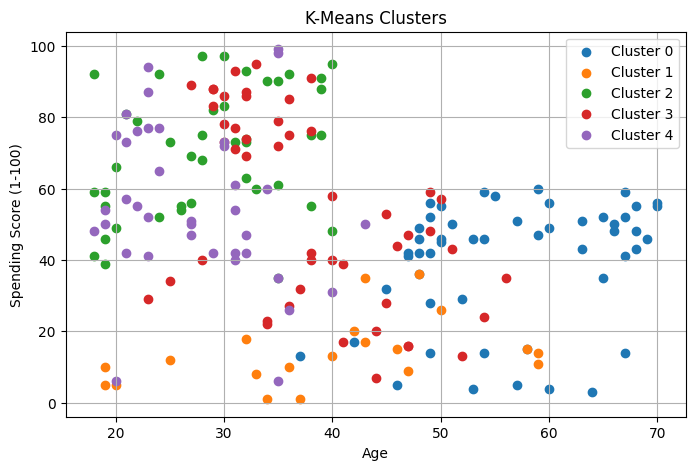

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0           1      1   19                  15                      39        2
1           2      1   21                  15                      81        2
2           3      0   20                  16                       6        4
3           4      0   23                  16                      77        4
4           5      0   31                  17                      40        4


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv("/content/Mall_Customers.csv")
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})
X = df[['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method - Choosing Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(8,5))
for cluster in range(k):
    plt.scatter(df[df['Cluster'] == cluster]['Age'],
                df[df['Cluster'] == cluster]['Spending Score (1-100)'],
                label=f'Cluster {cluster}')
plt.title('K-Means Clusters')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()
print(df.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])

In [ ]:
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

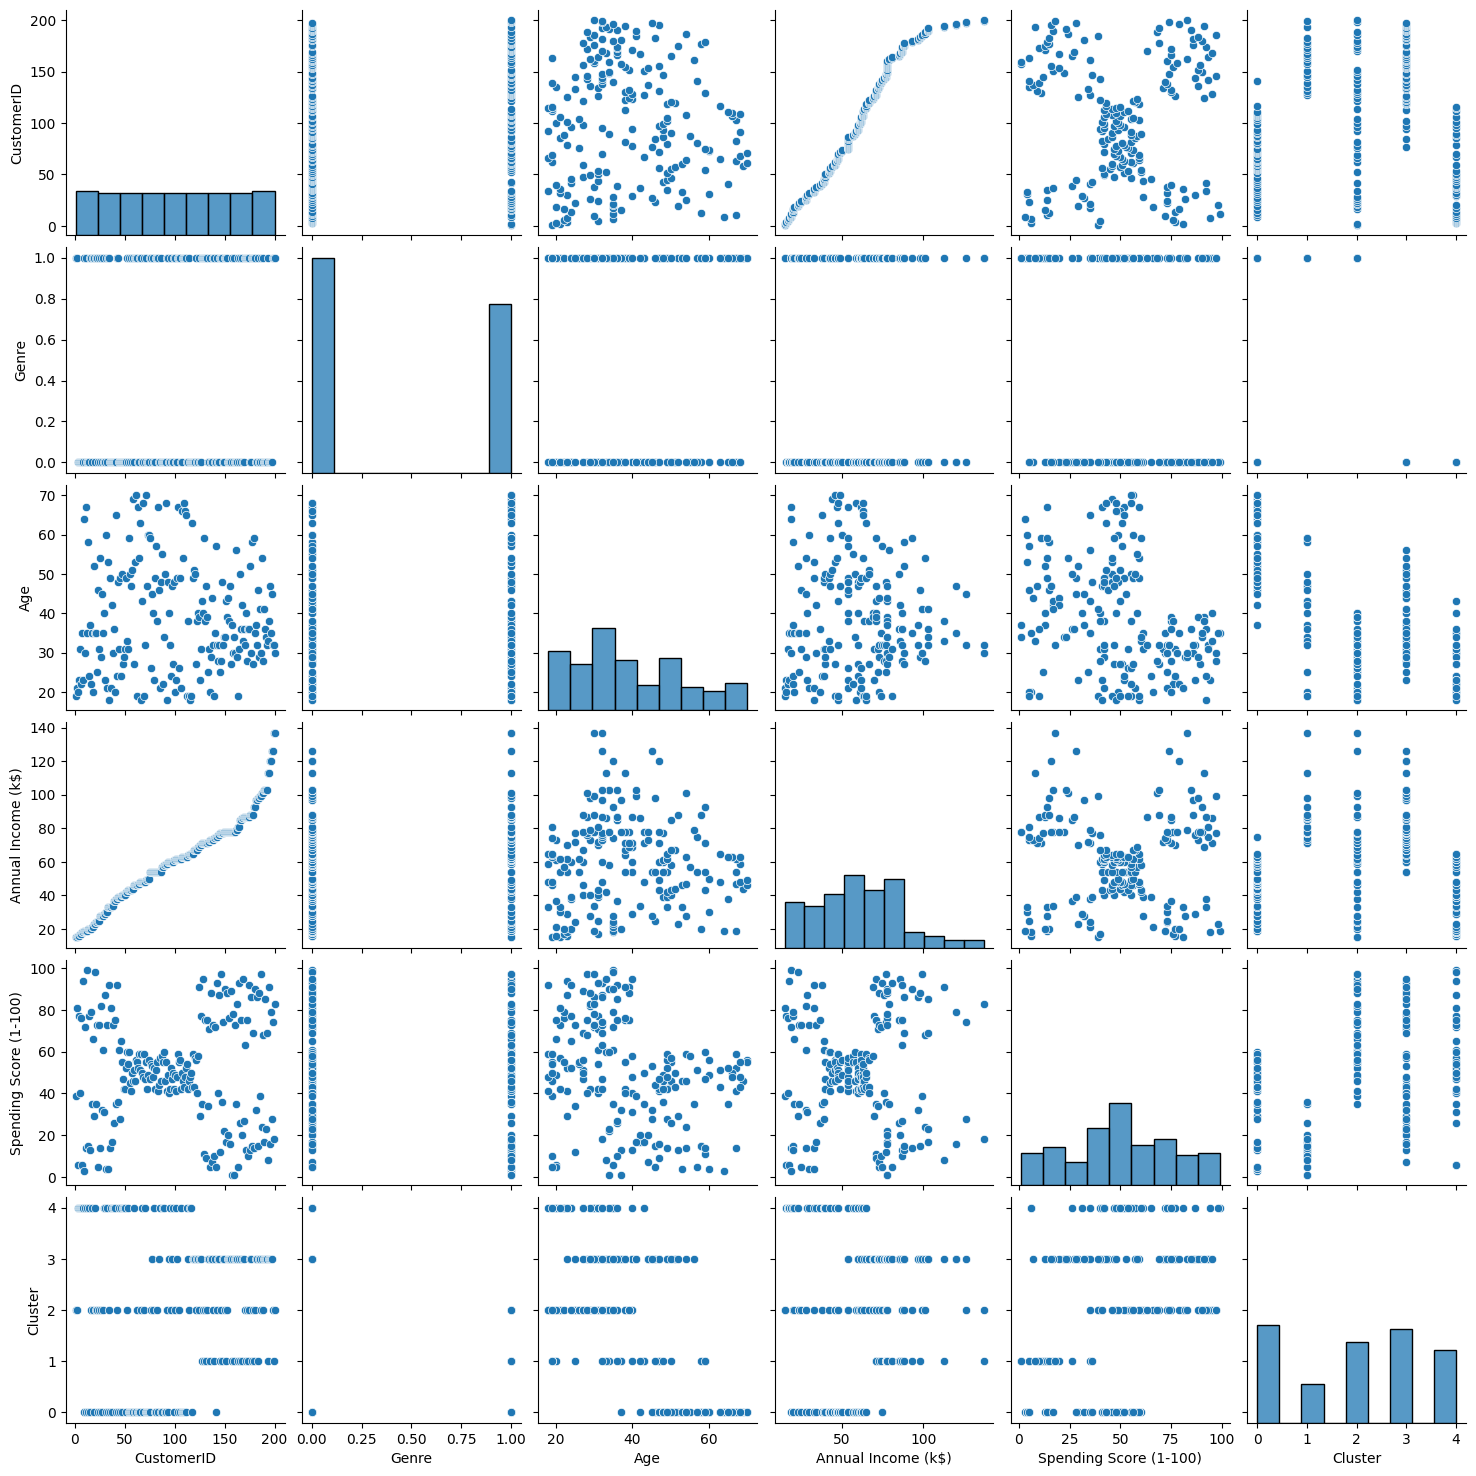

In [ ]:
sns.pairplot(df)
plt.show()

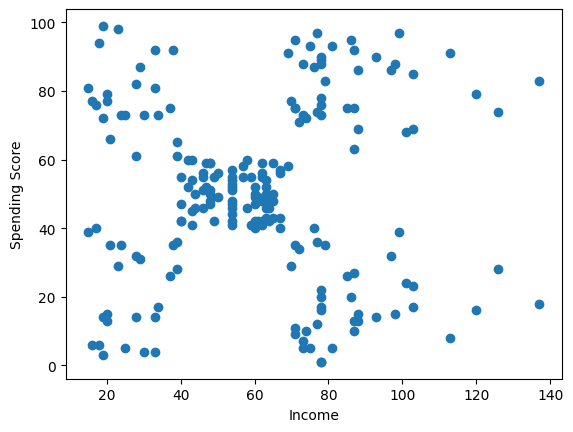

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

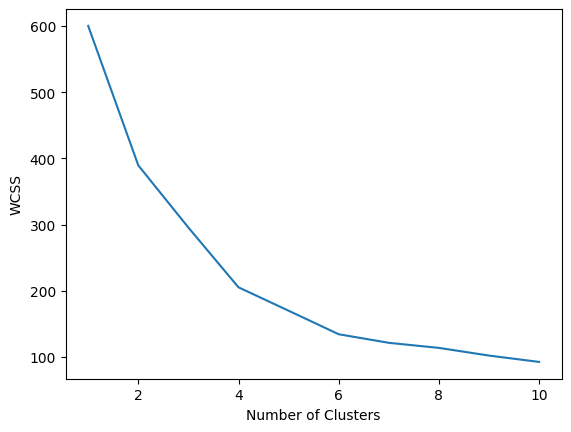

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

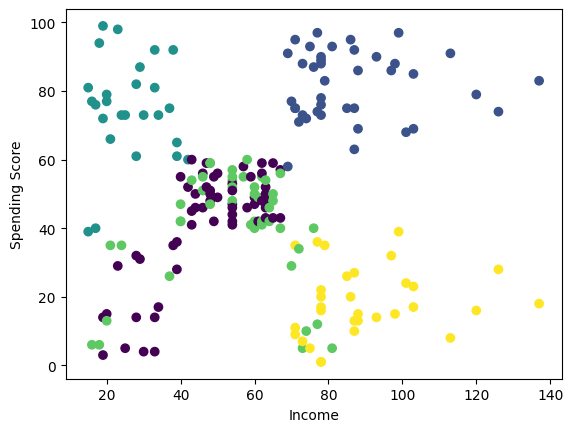

In [ ]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=clusters)
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.show()

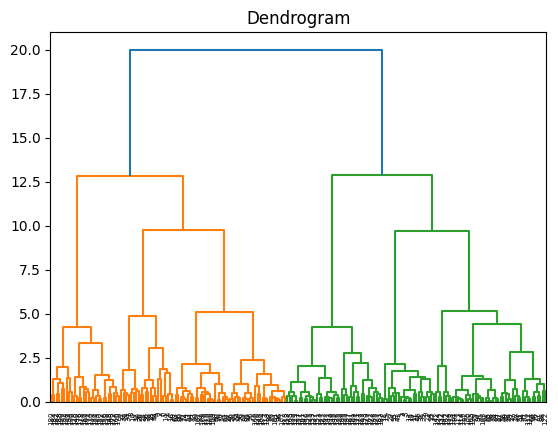

In [ ]:
import scipy.cluster.hierarchy as sch

dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Dendrogram")
plt.show()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
hc_clusters = hc.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hc_clusters

In [ ]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = db_clusters

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

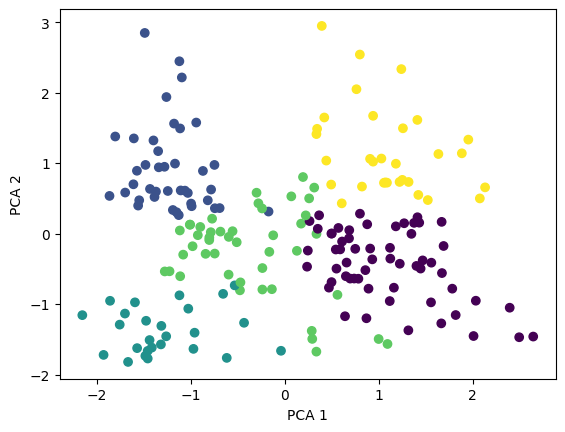

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB

In [36]:
models = {

"Logistic Regression": LogisticRegression(),
"KNN": KNeighborsClassifier(),
"SVM": SVC(),
"Decision Tree": DecisionTreeClassifier(),
"Random Forest": RandomForestClassifier(),
"Gradient Boosting": GradientBoostingClassifier(),
"AdaBoost": AdaBoostClassifier(),
"Naive Bayes": GaussianNB()

}

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1])

In [39]:
comparison = pd.DataFrame(results, columns=[
"Model","Accuracy","Precision","Recall","F1 Score"
])

comparison = comparison.sort_values(by="Accuracy", ascending=False)

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
3        Decision Tree     1.000   1.000000  1.000000  1.000000
2                  SVM     1.000   1.000000  1.000000  1.000000
5    Gradient Boosting     1.000   1.000000  1.000000  1.000000
4        Random Forest     1.000   1.000000  1.000000  1.000000
6             AdaBoost     1.000   1.000000  1.000000  1.000000
0  Logistic Regression     0.950   0.894737  1.000000  0.944444
1                  KNN     0.925   0.888889  0.941176  0.914286
7          Naive Bayes     0.925   0.937500  0.882353  0.909091


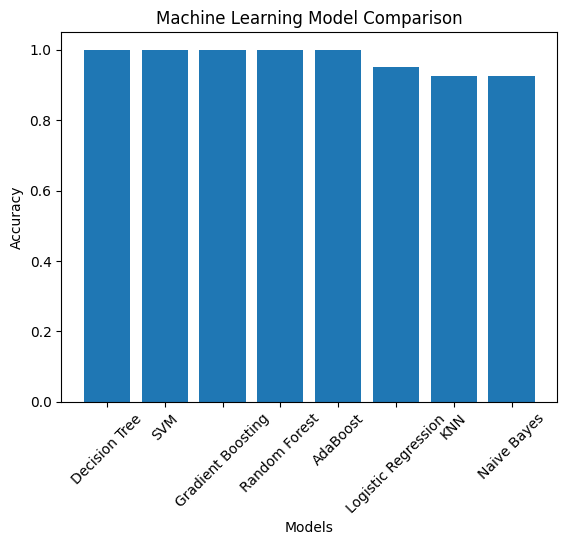

In [40]:
plt.figure()

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Machine Learning Model Comparison")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = df['KMeans_Cluster']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


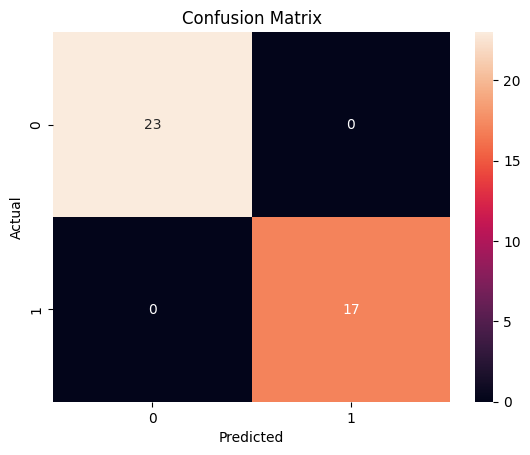

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.40846873777345605


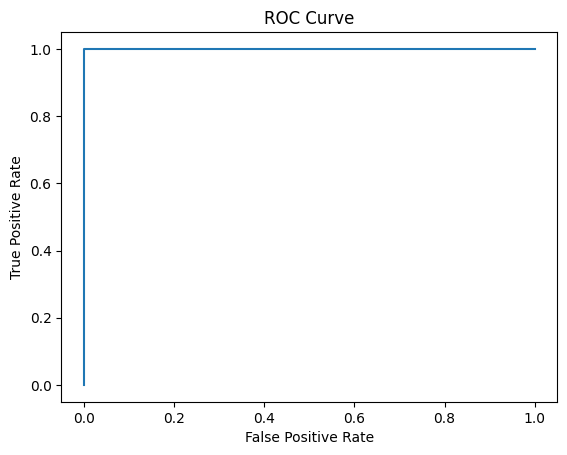

In [27]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

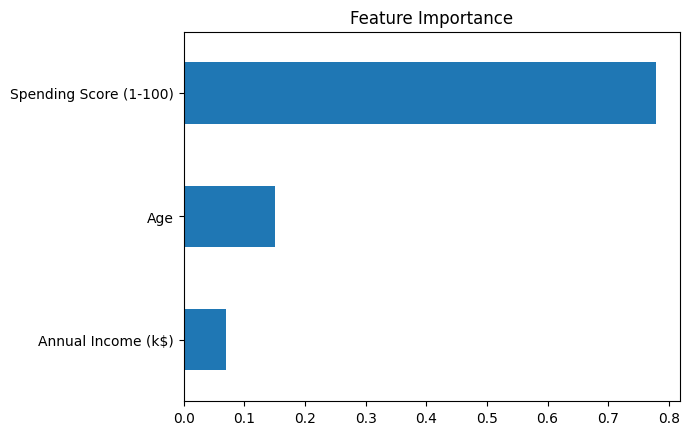

In [28]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:
df.to_csv("customer_segmentation_results.csv", index=False)

In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0


In [2]:
import pandas as pd

# Re-initialize df, assuming previous steps load and preprocess 'Genre'
df = pd.read_csv("/content/Mall_Customers.csv")
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})

df['Income_Age_Ratio'] = df['Annual Income (k$)'] / df['Age']

df['Age_Group'] = pd.cut(df['Age'],
                         bins=[18,25,35,50,70],
                         labels=['Young','Adult','MidAge','Senior'])

df['Income_Group'] = pd.cut(df['Annual Income (k$)'],
                            bins=[0,40,70,100,150],
                            labels=['Low','Medium','High','VeryHigh'])

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define X using the features previously used for clustering
X = df[['Age','Annual Income (k$)','Spending Score (1-100)']]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform KMeans clustering to get 'clusters'
k = 5 # Using k=5 as determined in previous cells
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters # Add this line to assign clusters to df

score = silhouette_score(X_scaled, clusters)
print(score)

0.41664341513732767


In [7]:
df['High_Spender'] = df['Spending Score (1-100)'].apply(lambda x: 1 if x>50 else 0)

In [17]:
!pip install streamlit
import streamlit as st

st.title("Customer Segmentation Dashboard")
st.write(df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 120.3 MB/s eta 0:00:00


2026-03-14 09:48:32.028 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 09:48:32.187 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-14 09:48:32.188 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 09:48:32.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 09:48:32.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 09:48:32.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-14 09:48:32.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


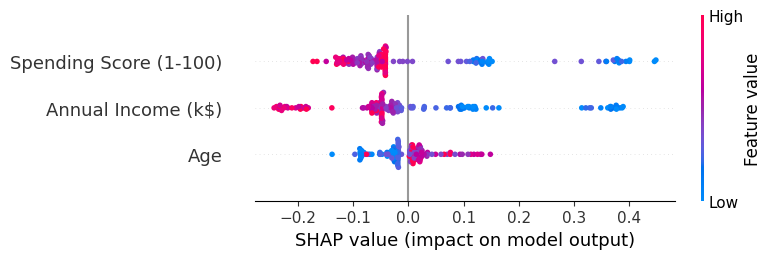

In [16]:
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Ensure y is defined and X_scaled is available
y = df['KMeans_Cluster']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and fit the RandomForestClassifier model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Now, the model should be fitted and ready for SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Get feature names from the original DataFrame for better plotting
feature_names = X.columns.tolist()

# Plotting for the first class (index 0) to avoid dimension mismatch
shap.summary_plot(shap_values[:, :, 0], X_train, feature_names=feature_names)

In [31]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

kmeans = KMeans(n_clusters=5)
k_labels = kmeans.fit_predict(X_scaled)

dbscan = DBSCAN(eps=0.5)
d_labels = dbscan.fit_predict(X_scaled)

hier = AgglomerativeClustering(n_clusters=5)
h_labels = hier.fit_predict(X_scaled)

k_score = silhouette_score(X_scaled, k_labels)
d_score = silhouette_score(X_scaled, d_labels)
h_score = silhouette_score(X_scaled, h_labels)

print("KMeans Score:", k_score)
print("DBSCAN Score:", d_score)
print("Hierarchical Score:", h_score)

KMeans Score: 0.40846873777345605
DBSCAN Score: 0.18451372756506046
Hierarchical Score: 0.39002826186267214


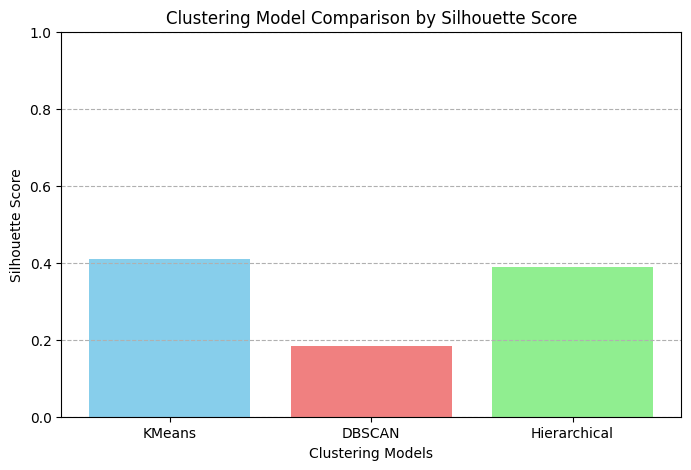

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the comparison DataFrame using the calculated scores
models = ["KMeans", "DBSCAN", "Hierarchical"]
scores = [k_score, d_score, h_score]

comparison = pd.DataFrame({
    "Model": models,
    "Silhouette Score": scores
})

plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["Silhouette Score"], color=['skyblue', 'lightcoral', 'lightgreen'])

plt.xlabel("Clustering Models")
plt.ylabel("Silhouette Score")
plt.title("Clustering Model Comparison by Silhouette Score")
plt.ylim(0, 1) # Silhouette scores range from -1 to 1
plt.grid(axis='y', linestyle='--')

plt.show()

In [34]:
plt.savefig("model_comparison_graph.png")

<Figure size 640x480 with 0 Axes>